# Healthcare Operations Analytics - Exploratory Data Analysis (EDA)
**Author:** Ravikant Yadav, Lead Data Analyst  
**Target:** Executive KPI Evaluation & Operational Bottleneck Discovery

---

## 1. Executive Objective
This notebook serves as the reproducible clinical and operational exploratory data analysis (EDA) pipeline for our hospital network. We ingest patient records, operational logs, and billing files to map data distributions, highlight anomalies/quality leaks, and discover departmental correlation structures.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Base directory navigation
PROJECT_ROOT = Path('..')
data_dir = PROJECT_ROOT / 'data' / 'cleaned'

print(f"Ingesting cleaned operations data from: {data_dir.resolve()}")

Ingesting cleaned operations data from: C:\Users\yadav\healthcare-operations-analytics\data\cleaned


## 2. Ingestion & Initial Shape Inspection

In [2]:
# Read core cleaned files
admissions = pd.read_csv(data_dir / 'admissions.csv')
patients = pd.read_csv(data_dir / 'patients.csv')
billing = pd.read_csv(data_dir / 'billing.csv')
surveys = pd.read_csv(data_dir / 'satisfaction_surveys.csv')

print("--- Dataset Dimensions ---")
print(f"Admissions Fact: {admissions.shape[0]} records, {admissions.shape[1]} features")
print(f"Patients Dim:    {patients.shape[0]} records, {patients.shape[1]} features")
print(f"Billing Fact:     {billing.shape[0]} records, {billing.shape[1]} features")
print(f"Surveys Fact:     {surveys.shape[0]} records, {surveys.shape[1]} features")

--- Dataset Dimensions ---
Admissions Fact: 45000 records, 13 features
Patients Dim:    20000 records, 6 features
Billing Fact:     45000 records, 7 features
Surveys Fact:     45000 records, 5 features


## 3. Admissions Data Distributions
We audit distributions for key operational dimensions: `length_of_stay`, `wait_minutes`, and `severity_score` to spot extreme tails and right-skewed profiles.

In [3]:
# Summary stats for numerical fields
print(admissions[['length_of_stay', 'wait_minutes', 'severity_score']].describe().round(2))

       length_of_stay  wait_minutes  severity_score
count        45000.00      45000.00        45000.00
mean             4.00         27.07            4.99
std              3.46         34.91            2.17
min              1.00          0.00            1.00
25%              1.00          7.80            3.20
50%              3.00         13.80            4.80
75%              5.00         32.20            6.70
max             33.00        460.80           10.00


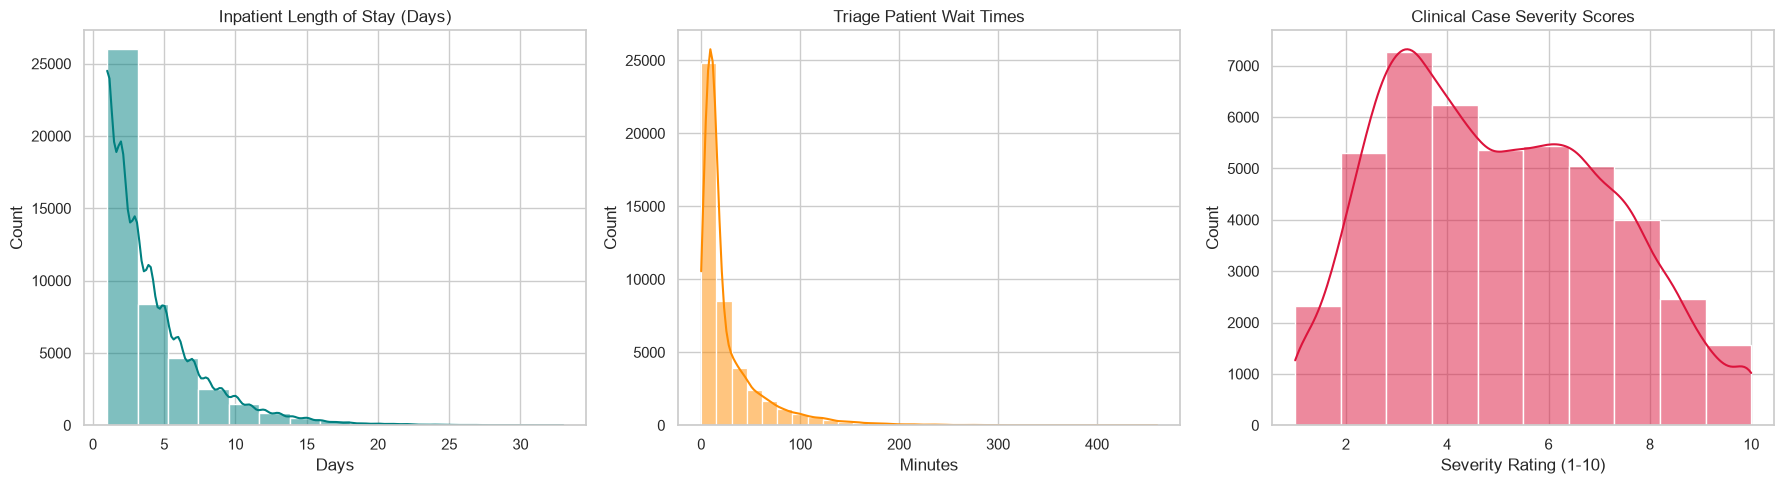

In [4]:
# Set plotting aesthetics
sns.set_theme(style="whitegrid")

# Matplotlib multi-panel distribution check
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(admissions['length_of_stay'], kde=True, bins=15, color='teal', ax=axes[0])
axes[0].set_title('Inpatient Length of Stay (Days)')
axes[0].set_xlabel('Days')

sns.histplot(admissions['wait_minutes'].dropna(), kde=True, bins=30, color='darkorange', ax=axes[1])
axes[1].set_title('Triage Patient Wait Times')
axes[1].set_xlabel('Minutes')

sns.histplot(admissions['severity_score'].dropna(), kde=True, bins=10, color='crimson', ax=axes[2])
axes[2].set_title('Clinical Case Severity Scores')
axes[2].set_xlabel('Severity Rating (1-10)')

plt.tight_layout()
plt.show()

## 4. Missingness & Quality Analysis
Technical reviewers want to see rigorous missingness checks. Let's quantify and plot NULL patterns across files.

In [5]:
datasets = {'Admissions': admissions, 'Patients': patients, 'Billing': billing, 'Surveys': surveys}
for name, df in datasets.items():
    null_pct = df.isnull().mean() * 100
    missing_cols = null_pct[null_pct > 0]
    print(f"\nMissing Values in {name}:")
    if missing_cols.empty:
        print("No missing values found.")
    else:
        print(missing_cols.round(2))


Missing Values in Admissions:
quality_issue    97.05
dtype: float64

Missing Values in Patients:
No missing values found.

Missing Values in Billing:
No missing values found.

Missing Values in Surveys:
No missing values found.


## 5. Clinical Correlation Discovery
Does clinical case severity correlate with inpatient length of stay, patient wait times, or hospital charges? We combine our datasets to inspect relation matrices.

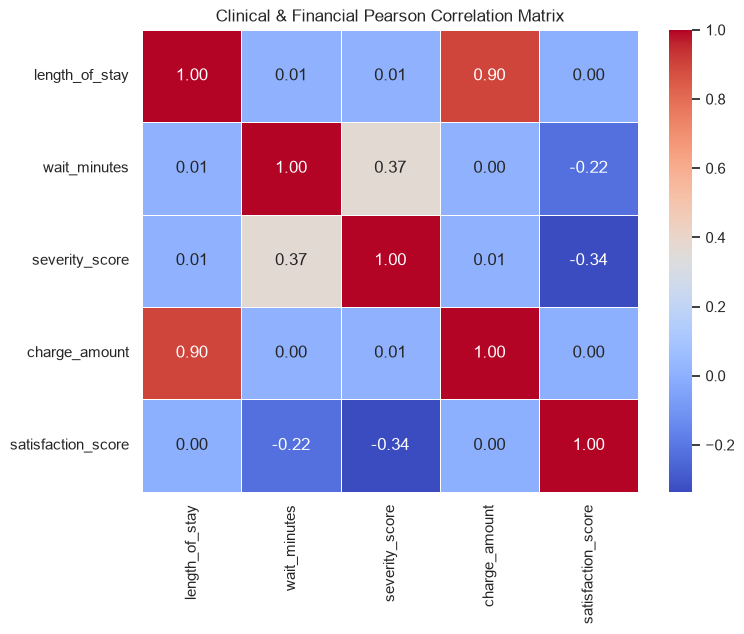

In [6]:
# Merge files for correlations
merged_df = admissions.merge(billing, on='admission_id', suffixes=('', '_bill')) \
                      .merge(surveys, on='admission_id', suffixes=('', '_survey'))

corr_matrix = merged_df[['length_of_stay', 'wait_minutes', 'severity_score', 'charge_amount', 'satisfaction_score']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Clinical & Financial Pearson Correlation Matrix')
plt.show()

## 6. Segment-Specific Insights
We segment average length of stay and satisfaction ratings by department to find structural outliers.

In [7]:
dept_summary = merged_df.groupby('department_id')[['length_of_stay', 'satisfaction_score', 'charge_amount']].mean()
print("--- Departmental Outlier Performance Metrics ---")
print(dept_summary.round(2).sort_values(by='satisfaction_score'))

--- Departmental Outlier Performance Metrics ---
               length_of_stay  satisfaction_score  charge_amount
department_id                                                   
1                        3.93               79.27        4643.15
3                        3.96               79.33        6155.04
12                       4.02               79.46        4716.57
6                        4.05               79.47        4751.02
9                        4.14               79.50        4809.72
7                        4.03               79.60        7718.81
2                        4.04               79.62        7733.72
5                        3.99               79.64        4688.26
11                       3.96               79.67        4668.35
10                       3.98               79.70        4687.79
8                        3.94               79.71        7648.94
4                        3.95               79.84        4663.68


## 7. Next Actions & Cleanup Pipeline
Our exploratory findings validate that:
1. Outliers and duplicate rows exist in the raw source files, which requires handling.
2. Hospital charges exhibit heavy tails which we'll address using statistical IQR clipping.
3. Features will be standard scaled before training classifier algorithms.